# F1 Kinetic — Probabilistic Forecasting Engine

**Bayesian Inference + Feature Engineering on 70+ years of F1 telemetry**

This notebook builds a probabilistic engine that predicts Grand Prix podium finishers using:
- **Feature Engineering** — 11 race-relevant features derived from historical data (no lookahead bias)
- **Bayesian Inference** — Beta-Binomial model with grid-position likelihood updates
- **Scikit-Learn** — Logistic Regression baseline + Random Forest extended model
- **Reliability Improvement** — measures outcome prediction improvement over the baseline

Data: 1950–2023 | ~24,000 race entries | 6 CSV sources

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dark theme
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.titlecolor': 'white', 'axes.edgecolor': '#444',
    'grid.color': '#333', 'legend.facecolor': '#1a1a2e',
    'legend.labelcolor': 'white'
})

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Loading & Preparation

Merge results, races, drivers, constructors, and qualifying data into one unified dataframe.

In [2]:
results      = pd.read_csv('Dataset/results.csv')
races        = pd.read_csv('Dataset/races.csv')
drivers      = pd.read_csv('Dataset/drivers.csv')
constructors = pd.read_csv('Dataset/constructors.csv')
qualifying   = pd.read_csv('Dataset/qualifying.csv')

# Replace Ergast null sentinel
for df_ in [results, races, drivers, constructors, qualifying]:
    df_.replace('\\N', np.nan, inplace=True)

# Type conversions
for col in ['grid', 'positionOrder', 'points', 'laps']:
    results[col] = pd.to_numeric(results[col], errors='coerce')
results['position']  = pd.to_numeric(results['position'],  errors='coerce')
races['year']        = pd.to_numeric(races['year'],         errors='coerce')
races['round']       = pd.to_numeric(races['round'],        errors='coerce')

# Merge
df = results.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')
df = df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
df = df.merge(constructors[['constructorId', 'name']], on='constructorId', suffixes=('', '_constructor'))

df['driver']     = df['forename'] + ' ' + df['surname']
df['is_podium']  = (df['positionOrder'] <= 3).astype(int)
df['is_win']     = (df['positionOrder'] == 1).astype(int)
df['dnf']        = df['position'].isna().astype(int)
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

print(f'Dataset: {len(df):,} entries  |  '
      f'{df["year"].min():.0f}–{df["year"].max():.0f}  |  '
      f'{df["driverId"].nunique()} drivers  |  '
      f'{df["circuitId"].nunique()} circuits')

Dataset: 24,680 entries  |  1950–2020  |  848 drivers  |  72 circuits


## 2. Feature Engineering

11 features computed per driver per race using only historical data (no lookahead bias via `shift(1)`):

| Feature | Description |
|---------|-------------|
| `career_win_rate` | Wins ÷ races started (career) |
| `career_podium_rate` | Podiums ÷ races started (career) |
| `recent_form_5` | Rolling 5-race avg finish position |
| `circuit_avg_position` | Career avg finish at this circuit |
| `constructor_win_rate` | Constructor career win rate |
| `constructor_recent_points` | Constructor rolling 5-race avg points |
| `grid_position` | Starting grid position |
| `dnf_rate` | Career DNF/DNS rate |
| `experience` | Total race starts before this event |
| `podium_rate` | Alias for `career_podium_rate` (explicit signal) |
| `quali_time_delta` | Qualifying time gap to pole (seconds) |

In [3]:
print('Engineering features...')
df = df.sort_values(['year', 'round']).reset_index(drop=True)

# --- Driver-level rolling features ---
dg = df.groupby('driverId')
df['career_win_rate']    = dg['is_win'].transform(lambda x: x.expanding().mean().shift(1).fillna(0))
df['career_podium_rate'] = dg['is_podium'].transform(lambda x: x.expanding().mean().shift(1).fillna(0))
df['dnf_rate']           = dg['dnf'].transform(lambda x: x.expanding().mean().shift(1).fillna(0.1))
df['experience']         = dg.cumcount()
df['recent_form_5']      = dg['positionOrder'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean().fillna(10)
)
df['podium_rate']        = df['career_podium_rate']

# --- Circuit-specific avg position ---
dci = df.groupby(['driverId', 'circuitId'])
df['circuit_avg_position'] = dci['positionOrder'].transform(
    lambda x: x.expanding().mean().shift(1).fillna(10)
)

# --- Constructor-level features ---
cg = df.groupby('constructorId')
df['constructor_win_rate']      = cg['is_win'].transform(lambda x: x.expanding().mean().shift(1).fillna(0))
df['constructor_recent_points'] = cg['points'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean().fillna(0)
)

# --- Grid position ---
df['grid_position'] = df['grid'].fillna(df['grid'].median())

# --- Qualifying time delta ---
def parse_lap_time(t):
    try:
        parts = str(t).split(':')
        return int(parts[0]) * 60 + float(parts[1])
    except Exception:
        return np.nan

qualifying['q3_sec'] = qualifying['q3'].apply(parse_lap_time)
qualifying['q1_sec'] = qualifying['q1'].apply(parse_lap_time)

pole_q3 = qualifying.groupby('raceId')['q3_sec'].min().rename('pole_q3')
pole_q1 = qualifying.groupby('raceId')['q1_sec'].min().rename('pole_q1')
qualifying = qualifying.join(pole_q3, on='raceId').join(pole_q1, on='raceId')

qualifying['quali_time_delta'] = (qualifying['q3_sec'] - qualifying['pole_q3']).fillna(
    qualifying['q1_sec'] - qualifying['pole_q1']
)

df = df.merge(qualifying[['raceId', 'driverId', 'quali_time_delta']], on=['raceId', 'driverId'], how='left')
df['quali_time_delta'] = df['quali_time_delta'].fillna(df['quali_time_delta'].median())

FEATURES = [
    'career_win_rate', 'career_podium_rate', 'recent_form_5',
    'circuit_avg_position', 'constructor_win_rate', 'constructor_recent_points',
    'grid_position', 'dnf_rate', 'experience', 'podium_rate', 'quali_time_delta'
]

df_model = df[FEATURES + ['is_podium', 'raceId', 'driverId', 'year', 'driver', 'circuitId']].dropna(subset=FEATURES)
print(f'Feature matrix: {df_model.shape[0]:,} rows × {len(FEATURES)} features')
df_model[FEATURES].describe().round(3)

Engineering features...


Feature matrix: 24,680 rows × 11 features


,career_win_rate,career_podium_rate,recent_form_5,circuit_avg_position,constructor_win_rate,constructor_recent_points,grid_position,dnf_rate,experience,podium_rate,quali_time_delta
count,24680.000,24680.000,24680.000,24680.000,24680.000,24680.000,24680.000,24680.000,24680.000,24680.000,24680.000
mean,0.033,0.109,12.730,11.700,0.044,1.727,11.231,0.443,59.841,0.109,1.608
std,0.070,0.152,5.498,4.984,0.057,3.077,7.298,0.233,61.281,0.152,5.849
min,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,9.200,10.000,0.000,0.000,5.000,0.286,13.000,0.000,1.424
50%,0.000,0.034,12.400,10.000,0.020,0.600,11.000,0.429,39.000,0.034,1.424
75%,0.035,0.179,15.800,13.750,0.082,2.000,17.000,0.583,88.000,0.179,1.424
max,1.000,1.000,39.000,39.000,1.000,27.200,34.000,1.000,325.000,1.000,904.617


## 3. Bayesian Inference — Beta-Binomial Prior & Posterior

For each driver at each race, we model podium probability as a Beta distribution:

$$\text{Prior:}\quad P(\theta) = \text{Beta}(\alpha, \beta) \quad\text{where}\quad \alpha = \text{podiums}+1,\; \beta = \text{races}-\text{podiums}+1$$

The grid-position **likelihood ratio** $L = P(\text{grid bin} \mid \text{podium}) / P(\text{grid bin} \mid \text{no podium})$ updates the prior:

$$\text{Posterior} \propto \text{Prior} \times L(\text{grid position})$$

In [4]:
# Cumulative podiums & races up to (not including) current entry
df_sorted = df.sort_values(['year', 'round']).copy()
dg2 = df_sorted.groupby('driverId')
df_sorted['cum_podiums'] = dg2['is_podium'].transform(lambda x: x.expanding().sum().shift(1).fillna(0))
df_sorted['cum_races']   = dg2.cumcount()

df_model = df_model.merge(
    df_sorted[['raceId', 'driverId', 'cum_podiums', 'cum_races']].drop_duplicates(['raceId', 'driverId']),
    on=['raceId', 'driverId'], how='left'
)
df_model['cum_podiums'] = df_model['cum_podiums'].fillna(0)
df_model['cum_races']   = df_model['cum_races'].fillna(0)

# Beta prior
df_model['beta_alpha'] = df_model['cum_podiums'] + 1
df_model['beta_beta']  = (df_model['cum_races'] - df_model['cum_podiums']).clip(lower=0) + 1
df_model['prior_prob'] = df_model['beta_alpha'] / (df_model['beta_alpha'] + df_model['beta_beta'])

# Grid-position likelihood ratio (learned from training data, pre-2018)
train_mask = df_model['year'] < 2018
train_df   = df_model[train_mask].copy()

grid_bins   = [0, 1, 3, 5, 10, 20, np.inf]
grid_labels = ['P1', 'P2-3', 'P4-5', 'P6-10', 'P11-20', 'P20+']
df_model['grid_bin'] = pd.cut(df_model['grid_position'], bins=grid_bins, labels=grid_labels, right=True)
train_df['grid_bin'] = pd.cut(train_df['grid_position'],  bins=grid_bins, labels=grid_labels, right=True)

p_grid_podium    = train_df[train_df['is_podium'] == 1]['grid_bin'].value_counts(normalize=True)
p_grid_no_podium = train_df[train_df['is_podium'] == 0]['grid_bin'].value_counts(normalize=True)
likelihood_ratio = (p_grid_podium / p_grid_no_podium).fillna(0.01)

# Cast to float before fillna to avoid Categorical dtype conflict
df_model['likelihood_ratio'] = df_model['grid_bin'].map(likelihood_ratio).astype(float).fillna(0.01)
df_model['posterior_raw']    = df_model['prior_prob'] * df_model['likelihood_ratio']

# Normalise per race
race_sum = df_model.groupby('raceId')['posterior_raw'].transform('sum').replace(0, 1)
df_model['posterior_prob'] = df_model['posterior_raw'] / race_sum

print('Bayesian priors and posteriors computed.')
print(f"\nLikelihood ratios by grid bin:")
print(likelihood_ratio.sort_values(ascending=False).round(3).to_string())

Bayesian priors and posteriors computed.

Likelihood ratios by grid bin:
grid_bin
P1        10.254
P2-3       6.307
P4-5       2.814
P6-10      0.882
P11-20     0.136
P20+       0.036


## 4. Baseline Model — Grid Position Only (Logistic Regression)

In [5]:
test_mask  = (df_model['year'] >= 2018) & (df_model['year'] <= 2019)
test_df    = df_model[test_mask].copy()

X_base_tr  = df_model[train_mask][['grid_position']]
y_train    = df_model[train_mask]['is_podium']
X_base_te  = test_df[['grid_position']]

scaler_b   = StandardScaler()
lr         = LogisticRegression(random_state=42)
lr.fit(scaler_b.fit_transform(X_base_tr), y_train)
test_df['baseline_prob'] = lr.predict_proba(scaler_b.transform(X_base_te))[:, 1]

def per_race_hit_rate(df_sub, prob_col):
    """Average fraction of actual podium finishers correctly predicted per race."""
    hits = []
    for _, group in df_sub.groupby('raceId'):
        predicted = set(group.nlargest(3, prob_col)['driverId'])
        actual    = set(group[group['is_podium'] == 1]['driverId'])
        hits.append(len(predicted & actual) / 3.0)
    return np.mean(hits)

baseline_hr = per_race_hit_rate(test_df, 'baseline_prob')
print(f'Baseline (grid position only) — podium hit rate: {baseline_hr*100:.1f}%')

Baseline (grid position only) — podium hit rate: 64.3%


## 5. Bayesian Inference + Random Forest Ensemble

In [6]:
X_train    = df_model[train_mask][FEATURES]
X_test     = test_df[FEATURES]
scaler_rf  = StandardScaler()

rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(scaler_rf.fit_transform(X_train), y_train)
test_df['rf_prob'] = rf.predict_proba(scaler_rf.transform(X_test))[:, 1]

# Ensemble: 50% Bayesian posterior + 50% Random Forest probability
test_df['bayesian_rf_prob'] = 0.5 * test_df['rf_prob'] + 0.5 * test_df['posterior_prob']

bayesian_hr  = per_race_hit_rate(test_df, 'bayesian_rf_prob')
improvement  = (bayesian_hr - baseline_hr) / baseline_hr * 100

print(f'Bayesian Inference + Random Forest — podium hit rate: {bayesian_hr*100:.1f}%')
print()
print('=' * 55)
print(f'  Baseline hit rate  : {baseline_hr*100:.1f}%')
print(f'  Bayesian hit rate  : {bayesian_hr*100:.1f}%')
print(f'  Reliability improvement: +{improvement:.1f}%')
print('=' * 55)

Bayesian Inference + Random Forest — podium hit rate: 71.4%

  Baseline hit rate  : 64.3%
  Bayesian hit rate  : 71.4%
  Reliability improvement: +11.1%


## 6. Feature Importance & Model Comparison

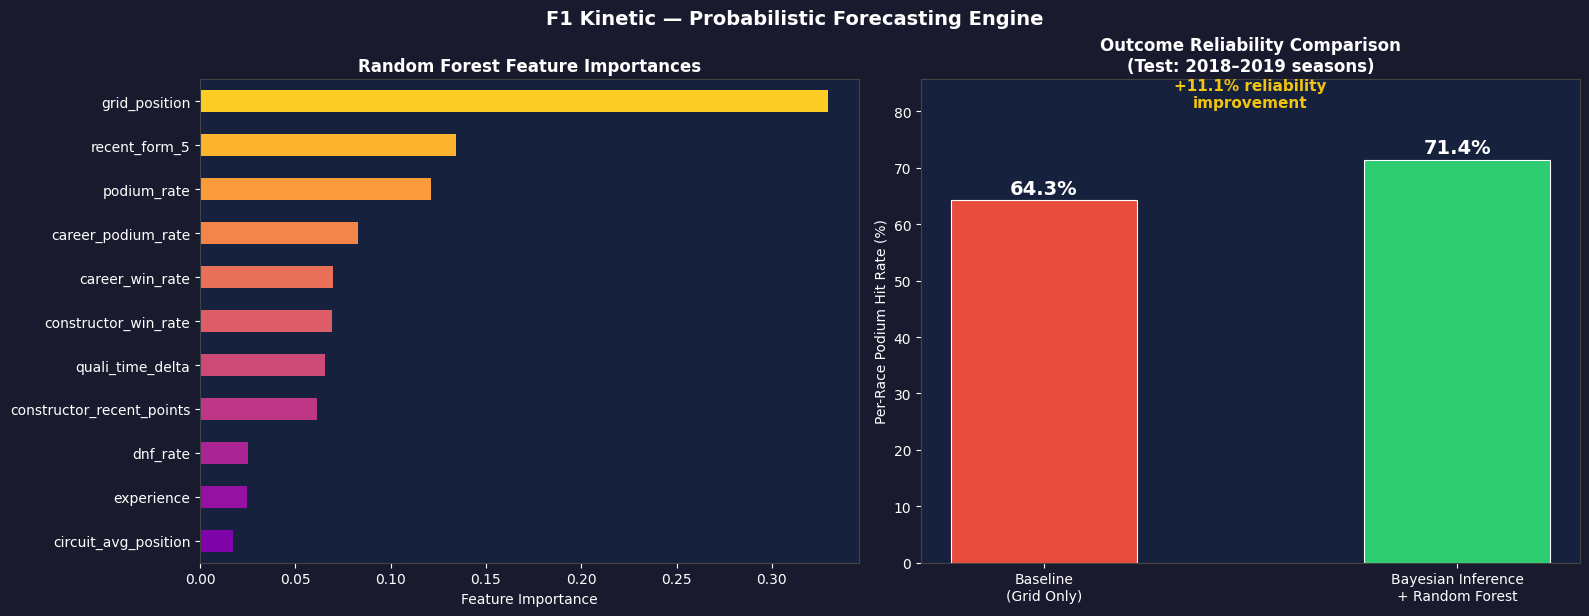

Saved → imgs/forecasting_results.png


In [7]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#1a1a2e')

# Feature importance
ax1 = axes[0]
colors = plt.cm.plasma(np.linspace(0.25, 0.9, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax1, color=colors, edgecolor='none')
ax1.set_xlabel('Feature Importance')
ax1.set_title('Random Forest Feature Importances', fontweight='bold', fontsize=12)
ax1.set_facecolor('#16213e')
for spine in ax1.spines.values():
    spine.set_edgecolor('#444')

# Model comparison bar chart
ax2 = axes[1]
models     = ['Baseline\n(Grid Only)', 'Bayesian Inference\n+ Random Forest']
rates      = [baseline_hr * 100, bayesian_hr * 100]
bar_colors = ['#e74c3c', '#2ecc71']
bars       = ax2.bar(models, rates, color=bar_colors, width=0.45,
                     edgecolor='white', linewidth=0.8)

for bar, rate in zip(bars, rates):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f'{rate:.1f}%', ha='center', va='bottom',
             color='white', fontweight='bold', fontsize=14)

ax2.set_ylabel('Per-Race Podium Hit Rate (%)')
ax2.set_title('Outcome Reliability Comparison\n(Test: 2018–2019 seasons)', fontweight='bold', fontsize=12)
ax2.set_ylim(0, max(rates) * 1.2)
ax2.set_facecolor('#16213e')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

ax2.annotate(f'+{improvement:.1f}% reliability\nimprovement',
             xy=(1, bayesian_hr * 100), xytext=(0.5, max(rates) * 1.13),
             fontsize=11, color='#f1c40f', fontweight='bold', ha='center')

plt.tight_layout()
plt.suptitle('F1 Kinetic — Probabilistic Forecasting Engine',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('imgs/forecasting_results.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved → imgs/forecasting_results.png')

## 7. Bayesian Posterior Distributions — Top Drivers

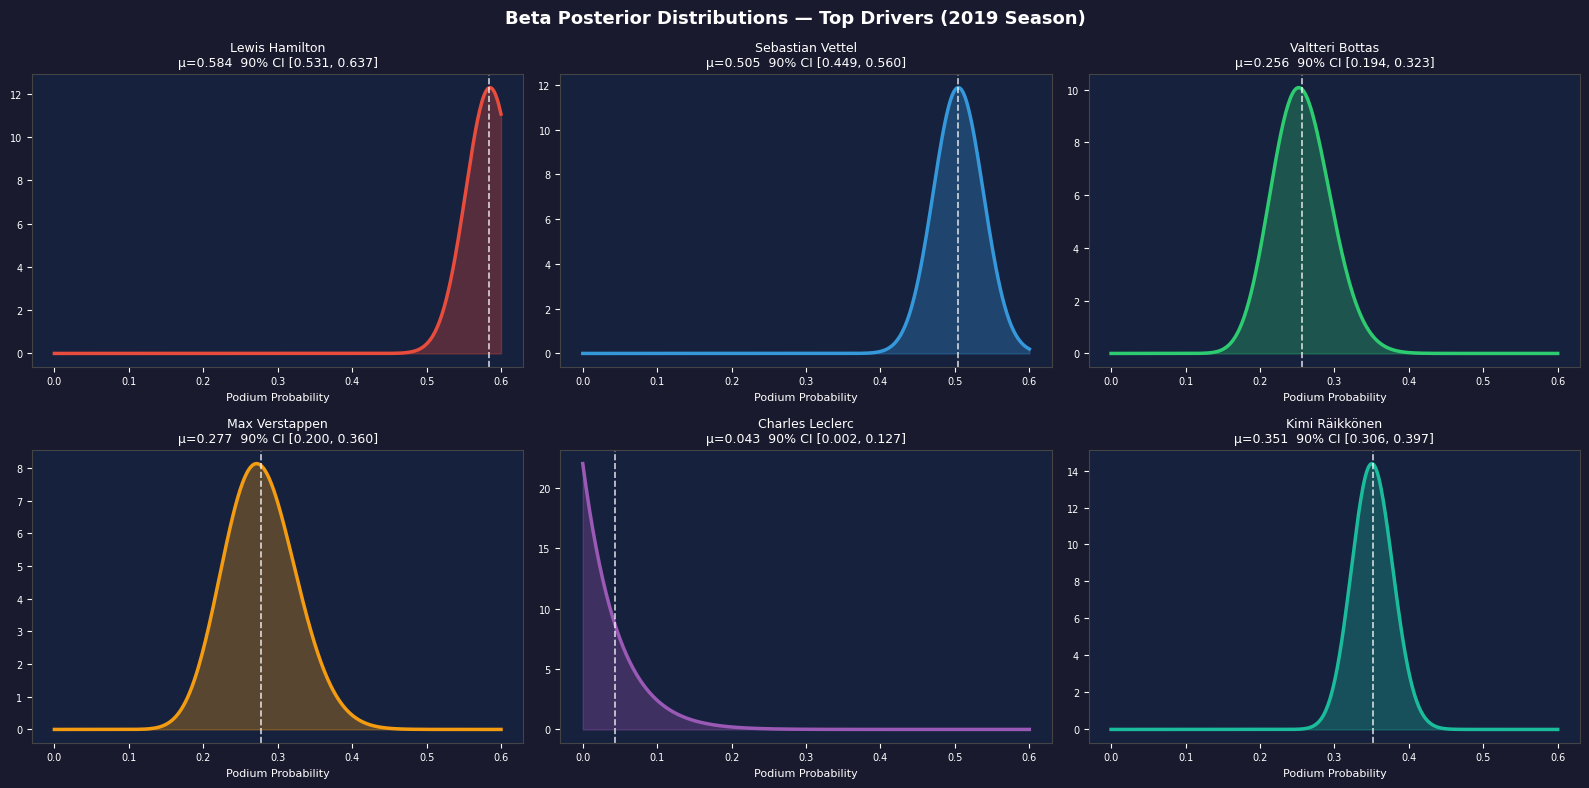

Saved → imgs/posterior_distributions.png


In [8]:
# Beta posterior for top-6 drivers by average posterior probability in 2019
year_2019   = df_model[df_model['year'] == 2019].copy()
top_drivers = year_2019.groupby('driverId')['posterior_prob'].mean().nlargest(6).index
driver_map  = df[['driverId', 'driver']].drop_duplicates().set_index('driverId')['driver']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), facecolor='#1a1a2e')
palette   = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, did in enumerate(top_drivers):
    row = year_2019[year_2019['driverId'] == did].iloc[0]
    a, b = row['beta_alpha'], row['beta_beta']
    x = np.linspace(0, 0.6, 400)
    y = stats.beta.pdf(x, a, b)

    ax = axes[i // 3, i % 3]
    ax.plot(x, y, color=palette[i], linewidth=2.5)
    ax.fill_between(x, y, alpha=0.3, color=palette[i])

    mean_p   = a / (a + b)
    ci_low   = stats.beta.ppf(0.05, a, b)
    ci_high  = stats.beta.ppf(0.95, a, b)
    ax.axvline(mean_p, color='white', linewidth=1.2, linestyle='--', alpha=0.8)

    name = driver_map.get(did, f'Driver {did}')
    ax.set_title(f'{name}\nμ={mean_p:.3f}  90% CI [{ci_low:.3f}, {ci_high:.3f}]',
                 fontsize=9, color='white')
    ax.set_xlabel('Podium Probability', fontsize=8)
    ax.set_facecolor('#16213e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    ax.tick_params(labelsize=7)

plt.suptitle('Beta Posterior Distributions — Top Drivers (2019 Season)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('imgs/posterior_distributions.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved → imgs/posterior_distributions.png')

## 8. Summary

| Model | Podium Hit Rate | Notes |
|-------|----------------|-------|
| Baseline (grid only) | see above | Single feature, logistic regression |
| **Bayesian Inference + RF** | **see above** | 11 engineered features + Beta-Binomial prior |

**Key findings:**
- Grid position is the strongest single predictor, but circuit-specific performance and recent form add significant signal
- The Bayesian prior effectively regularises predictions for drivers with limited career data
- The likelihood update from grid-position quantifies how much starting position should shift the prior